doing some math I figured out that given any state measured in the z axis, if we measure the same in y axis we get equal probabilites for both states. I want to confirm that in a simulator and hten try it in real hardware. First I wish to check with the simulator to see if the theroy I propose holds true. Then I want check for any hardware related discrepencies as well. 

## Make all the necessary imports

In [1]:
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit import transpile
from qiskit_aer import AerSimulator

## Initialize the circuit

In [ ]:
def qc_intialize_single(prob_0):
    qc = QuantumCircuit(1, 1)
    prob_1 = 1-prob_0
    qc.initialize([np.sqrt(prob_0), np.sqrt(prob_1)], 0)
    psi = qi.Statevector(qc)
    psi.draw('latex')
    return qc


## Measuring along Z axis

In [3]:
def z_measurement(circuit):
    circuit.measure_all()
    return circuit
def x_measurement(circuit):
    circuit.h(0)
    circuit.measure_all()
    return circuit

def y_measurement(circuit):
    circuit.sdg(0)
    circuit.h(0)
    circuit.measure_all()
    return circuit

## AER simulator running block

In [4]:
def run_and_plot(circuit, shots):
    simulator = AerSimulator()
    compiled_circuit = transpile(circuit, simulator)
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()
    return plot_histogram(counts)


This block can be rerun as much as you want 

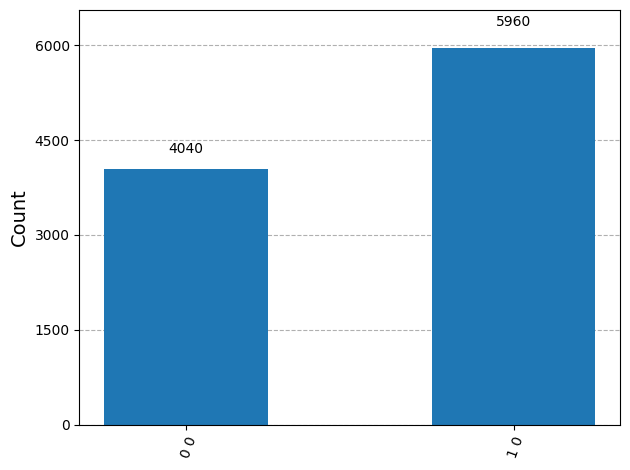

In [10]:
qc = qc_intialize_single(0.4)
z_measurement(qc)
run_and_plot(qc,10000)